# ATIVIDADE E PESQUISA PRÁTICA - Classificação de Sentimentos e Análise Comparativa

**Curso:** Ciência de Dados e IA – 3º ano  
**Disciplina:** Aprendizado de Máquina Supervisionado  
**Professor:** Bruno Faiçal  
**Instituição:** Universidade Estadual de Londrina (UEL)  
**Alunos:** 
- Lucas Antônio Cunha Rodrigues da Silva  
- Marcos Vinícius Beregula Ferreira  
- Michel Iago  

## 1. Objetivo
O objetivo desta atividade prática é automatizar a triagem de avaliações de produtos deixadas pelos usuários em uma plataforma de e-commerce, classificando-as em sentimentos **Positivos** (recomenda) ou **Negativos** (não recomenda).

O projeto compara duas abordagens distintas para solucionar esse problema:
1. **Abordagem Tradicional (Baseline):** Vetorização de palavras com TF-IDF e classificação através de Regressão Logística (com avaliação de três variantes progressivas de features).
2. **Abordagem de Deep Learning (Transformers):** Fine-tuning do modelo pré-treinado **DistilBERT Multilingual** para a classificação binária de texto.

In [1]:
# Imports e Configurações Iniciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

RANDOM_STATE=42

## 2. Dataset, Limpeza, Pré-processamento Comum e Balanceamento

O dataset utilizado é o **B2W-Reviews01**, contendo avaliações reais de e-commerce em português brasileiro.
Mapeamos o rótulo original `recommend_to_a_friend` da seguinte forma:
- `'yes'` $\rightarrow$ **1 (Sentimento Positivo)**
- `'no'` $\rightarrow$ **0 (Sentimento Negativo)**

Apenas colunas estritamente ligadas à linguagem e ao sentimento expresso na avaliação (`review_title`, `review_text`, `overall_rating`) são mantidas, isolando e avaliando a capacidade de previsão do modelo.

In [2]:
# Carga dos dados e Limpeza de Valores Ausentes
arquivo = '/Users/marcosvinicius/Desktop/codigos/faculdade/supervised_ml/trabalho_supervised_machine_learning/dados/B2W-Reviews01 - B2W-Reviews01.csv'
df = pd.read_csv(arquivo)

print("====== Informações do DataFrame Original ======")
df.info()

colunas = ['review_title', 'review_text', 'recommend_to_a_friend', 'overall_rating']

print("\n==== Quantidade de Valores Ausentes por Coluna (Antes) ====")
print(df[colunas].isna().sum())

# Remoção de nulos nas colunas de interesse
df.dropna(subset=colunas, inplace=True)

print("\n==== Quantidade de Valores Ausentes por Coluna (Depois) ====")
print(df[colunas].isna().sum())

# Mapeamento do rótulo para valor binário
y = df['recommend_to_a_friend'].str.lower().map({'yes': 1, 'no': 0})

# Remoção de colunas administrativas, identificadores ou demográficas extras
df.drop(columns=[
    'reviewer_id', 'recommend_to_a_friend', 'submission_date', 
    'product_id', 'product_name', 'product_brand', 
    'site_category_lv1', 'site_category_lv2', 
    'reviewer_birth_year', 'reviewer_gender', 'reviewer_state'
], inplace=True)

print("\n==== Estrutura do DataFrame Após Limpeza ====")
df.info()

print("\n==== Primeiras Linhas do DataFrame Final ====")
display(df.head())


====== Informações do DataFrame Original ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   submission_date        132373 non-null  object 
 1   reviewer_id            132373 non-null  object 
 2   product_id             132373 non-null  object 
 3   product_name           132289 non-null  object 
 4   product_brand          40982 non-null   object 
 5   site_category_lv1      132367 non-null  object 
 6   site_category_lv2      128360 non-null  object 
 7   review_title           132070 non-null  object 
 8   recommend_to_a_friend  132355 non-null  object 
 9   review_text            129098 non-null  object 
 10  overall_rating         132373 non-null  int64  
 11  reviewer_birth_year    126389 non-null  float64
 12  reviewer_gender        128237 non-null  object 
 13  reviewer_state         128382 non-null  o

/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_67986/3107435919.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)


,review_title,review_text,overall_rating
0,Bom,Estou contente com a compra entrega rápida o ú...,4
1,"Preço imbatível, ótima qualidade","Por apenas R$1994.20,eu consegui comprar esse ...",4
2,ATENDE TODAS AS EXPECTATIVA.,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,4
3,presente mais que desejado,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,4
4,"Sem duvidas, excelente","A entrega foi no prazo, as americanas estão de...",5


### 2.1 Análise da Variável Alvo (Target) e Entropia de Shannon

Antes de prosseguirmos para a etapa de modelagem ou balanceamento, é fundamental analisar a distribuição da nossa variável alvo (`recommend_to_a_friend` mapeada no rótulo `y`). Isso nos permite quantificar formalmente o grau de desbalanceamento e a incerteza contida nos dados através da **Entropia de Shannon**.

A Entropia de Shannon $H(Y)$ para uma variável aleatória discreta $Y$ é dada por:

$$H(Y) = -\sum_{i} P(y_i) \log_2 P(y_i)$$

No cenário de uma classificação binária:
- Uma entropia de **1.0 bit** representa o equilíbrio perfeito (distribuição 50/50), onde há máxima incerteza sobre a classe de um novo exemplo.
- Uma entropia de **0.0 bit** representa a homogeneidade total (todos os exemplos pertencem a uma única classe), onde não há incerteza alguma.

Abaixo, calculamos a entropia do nosso conjunto de dados original e visualizamos graficamente a distribuição das classes.

====== Análise da Variável Target Original ======
Classe 'Não Recomenda' (0): 33,945 amostras (26.34%)
Classe 'Recomenda' (1): 94,904 amostras (73.66%)
Entropia de Shannon: 0.8319 bits (valor máximo para binário = 1.0)


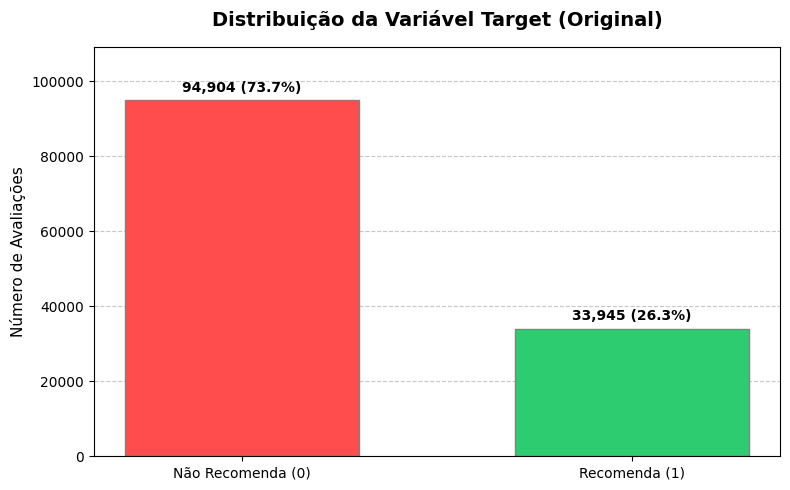

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# 1. Cálculo das frequências e proporções da variável target original
contagem = y.value_counts()
proporcoes = y.value_counts(normalize=True)

# 2. Cálculo da Entropia de Shannon (base 2 para classificação binária)
ent = entropy(proporcoes.values, base=2)

print("====== Análise da Variável Target Original ======")
print(f"Classe 'Não Recomenda' (0): {contagem[0]:,} amostras ({proporcoes[0]*100:.2f}%)")
print(f"Classe 'Recomenda' (1): {contagem[1]:,} amostras ({proporcoes[1]*100:.2f}%)")
print(f"Entropia de Shannon: {ent:.4f} bits (valor máximo para binário = 1.0)")

# 3. Visualização Gráfica da Distribuição
plt.figure(figsize=(8, 5))
colors = ['#ff4d4d', '#2ecc71']  # Vermelho e Verde limpos
bars = plt.bar(['Não Recomenda (0)', 'Recomenda (1)'], contagem.values, color=colors, edgecolor='grey', width=0.6)

# Adicionar rótulos de valores no topo das barras
for bar, prop in zip(bars, proporcoes.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 1500, 
             f"{int(height):,} ({prop*100:.1f}%)", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Distribuição da Variável Target (Original)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Número de Avaliações", fontsize=11)
plt.ylim(0, max(contagem.values) * 1.15)  # Espaço para os rótulos
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

### 2.2 Balanceamento de Classes

O conjunto de dados original apresenta um desbalanceamento relevante na coluna de destino `recommend_to_a_friend` (rótulo `y`):
- **Recomenda (1):** ~73.6% (94.904 amostras)
- **Não Recomenda (0):** ~26.4% (33.945 amostras)

Treinar modelos de classificação em conjuntos de dados desbalanceados pode fazer com que o classificador seja fortemente inclinado a prever a classe majoritária, reduzindo a sensibilidade do modelo para identificar a classe minoritária (neste caso, as avaliações negativas).

Para resolver isso, aplicamos a técnica de **Sub-amostragem Aleatória (Random Undersampling)** global no conjunto majoritário. Reduzimos o número de exemplos de sentimentos positivos para igualar a quantidade de sentimentos negativos (33.945 exemplos de cada classe). Isso gera um dataset perfeitamente equilibrado (50% / 50%) de **67.890 amostras**, o que também acelera significativamente o treinamento e otimiza o fluxo experimental comparativo.

In [ ]:
# Identificação dos índices correspondentes de cada classe em 'y'
idx_no = y[y == 0].index
idx_yes = y[y == 1].index

# Sub-amostragem da classe majoritária (yes/1) para equivaler à classe minoritária (no/0)
np.random.seed(RANDOM_STATE)  # Garantindo reprodutibilidade utilizando a semente global
idx_yes_sampled = np.random.choice(idx_yes, size=len(idx_no), replace=False)

# Combinação e embaralhamento dos índices
balanced_indices = np.concatenate([idx_no, idx_yes_sampled])
np.random.shuffle(balanced_indices)

# Filtragem e reset de índices para df e y
df = df.loc[balanced_indices].reset_index(drop=True)
y = y.loc[balanced_indices].reset_index(drop=True)

print("====== Informações após o Balanceamento ======")
print(f"Quantidade de amostras da classe 'Não Recomenda' (0): {sum(y == 0)}")
print(f"Quantidade de amostras da classe 'Recomenda' (1): {sum(y == 1)}")
print(f"Total de amostras no dataset balanceado: {len(df)}")

## 3. Abordagem Tradicional: TF-IDF + Regressão Logística

Nesta abordagem, convertemos as sentenças em representações de frequência numérica usando **TF-IDF** (*Term Frequency-Inverse Document Frequency*). 
As etapas clássicas de limpeza de texto aplicadas são:
1. **Lowercasing:** Unifica palavras em caixa alta/baixa.
2. **Strip Accents (Unicode):** Normaliza caracteres e remove acentos para reduzir a esparsidade do vocabulário.
3. **Remoção de Stopwords:** Despreza palavras que servem apenas como pontes gramaticais (ex.: "e", "de", "um").

> **Nota:** Para evitar a inconsistência na tokenização de stopwords acentuadas (como "não", "só") apontada pelo *scikit-learn*, removemos os acentos das próprias stopwords antes de passá-las ao vetorizador (fizemos isto no 3.2).

### 3.1 Função de Vetorização e Configuração de Features

In [3]:
# Configuração das features globais
df["review_plus_title"] = df["review_title"].astype(str) + " " + df["review_text"].astype(str)
ratings = df["overall_rating"]
review = df['review_text']
review_plus_title = df['review_plus_title']

# Função para normalizar e remover acentos das Stop Words em Português
def remover_acentos(texto):
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

stop_words_pt = [remover_acentos(w) for w in stopwords.words("portuguese")]

def vetorizar_e_combinar(X_train_rev, X_val_rev, X_train_fl, X_val_fl, r_train_raw, r_val_raw):
    # Caso 1: Apenas texto do Review
    vec_rev = TfidfVectorizer(lowercase=True, strip_accents='unicode', stop_words=stop_words_pt)
    X_train_v1 = vec_rev.fit_transform(X_train_rev)
    X_val_v1 = vec_rev.transform(X_val_rev)
    
    # Caso 2: Título + Texto do Review
    vec_fl = TfidfVectorizer(lowercase=True, strip_accents='unicode', stop_words=stop_words_pt)
    X_train_v2 = vec_fl.fit_transform(X_train_fl)
    X_val_v2 = vec_fl.transform(X_val_fl)
    
    # Caso 3: Título + Texto + Nota Numérica (Padronizada)
    scaler = StandardScaler()
    r_train_norm = scaler.fit_transform(r_train_raw.reshape(-1, 1))
    r_val_norm = scaler.transform(r_val_raw.reshape(-1, 1))
    
    X_train_v3 = hstack([X_train_v2, r_train_norm])
    X_val_v3 = hstack([X_val_v2, r_val_norm])
    
    return X_train_v1, X_val_v1, X_train_v2, X_val_v2, X_train_v3, X_val_v3


#### 📝 Nota Técnica: O papel do `hstack` na fusão de características textuais e numéricas

O vetorizador TF-IDF gera uma **matriz esparsa** (*sparse matrix*) para representar os textos (uma estrutura altamente eficiente onde apenas os termos presentes em cada avaliação são alocados em memória, ignorando a enorme quantidade de zeros). Por outro lado, a nota numérica (`overall_rating`) padronizada pelo `StandardScaler` é armazenada em uma estrutura de **matriz densa** tradicional.

Não podemos utilizar os métodos convencionais de concatenação direta de matrizes (como `np.concatenate` ou `np.hstack` do NumPy) porque eles forçariam a matriz esparsa a se converter em densa, o que consumiria gigabytes de memória RAM desnecessariamente e causaria erros de incompatibilidade de tipos.

A função `hstack` proveniente de `scipy.sparse` resolve essa limitação ao realizar o empilhamento horizontal de colunas mantendo a integridade e a esparsidade dos dados originais do TF-IDF. Dessa forma, acoplamos a nota numérica padronizada ao lado das colunas correspondentes às palavras, fornecendo uma matriz híbrida de features otimizada para o classificador clássico.

### 3.2 Execução da Validação Cruzada 10-Fold

In [4]:
# Execução da Validação Cruzada 10-Fold
from sklearn.model_selection import StratifiedKFold
from scipy import stats
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import unicodedata

# Configuração do StratifiedKFold (10 folds)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Arrays para as features e target
review_arr = review.values
full_arr = review_plus_title.values
ratings_arr = ratings.values.reshape(-1, 1)
y_arr = y.values

# Listas para guardar as acurácias de cada fold
accs_review_only = []
accs_title_plus_review = []
accs_over_filled = []

# Arrays para predições out-of-fold (OOF)
oof_preds_c1 = np.zeros(len(y_arr))
oof_preds_c2 = np.zeros(len(y_arr))
oof_preds_c3 = np.zeros(len(y_arr))

print("Iniciando a validação cruzada 10-Fold...")

for fold, (train_idx, val_idx) in enumerate(skf.split(review_arr, y_arr), 1):
    X_train_rev, X_val_rev = review_arr[train_idx], review_arr[val_idx]
    X_train_fl, X_val_fl = full_arr[train_idx], full_arr[val_idx]
    r_train_raw, r_val_raw = ratings_arr[train_idx], ratings_arr[val_idx]
    y_train_fold, y_val_fold = y_arr[train_idx], y_arr[val_idx]
    
    # Utilizando a função vetorizar_e_combinar
    X_train_v1, X_val_v1, X_train_v2, X_val_v2, X_train_v3, X_val_v3 = vetorizar_e_combinar(
        X_train_rev, X_val_rev, X_train_fl, X_val_fl, r_train_raw, r_val_raw
    )
    
    # 1. Caso 1: Apenas texto do Review
    clf1 = LogisticRegression(max_iter=500, random_state=42)
    clf1.fit(X_train_v1, y_train_fold)
    preds1 = clf1.predict(X_val_v1)
    accs_review_only.append(accuracy_score(y_val_fold, preds1))
    oof_preds_c1[val_idx] = preds1
    
    # 2. Caso 2: Título + Texto do Review
    clf2 = LogisticRegression(max_iter=500, random_state=42)
    clf2.fit(X_train_v2, y_train_fold)
    preds2 = clf2.predict(X_val_v2)
    accs_title_plus_review.append(accuracy_score(y_val_fold, preds2))
    oof_preds_c2[val_idx] = preds2
    
    # 3. Caso 3: Título + Texto + Nota Numérica (Padronizada)
    clf3 = LogisticRegression(max_iter=500, random_state=42)
    clf3.fit(X_train_v3, y_train_fold)
    preds3 = clf3.predict(X_val_v3)
    accs_over_filled.append(accuracy_score(y_val_fold, preds3))
    oof_preds_c3[val_idx] = preds3
    
    print(f"Fold {fold}/10 concluído. Acurácias - C1: {accs_review_only[-1]:.4f} | C2: {accs_title_plus_review[-1]:.4f} | C3: {accs_over_filled[-1]:.4f}")

# Convertendo para arrays do numpy
accs_c1 = np.array(accs_review_only)
accs_c2 = np.array(accs_title_plus_review)
accs_c3 = np.array(accs_over_filled)


Iniciando a validação cruzada 10-Fold...
Fold 1/10 concluído. Acurácias - C1: 0.9101 | C2: 0.9264 | C3: 0.9566
Fold 2/10 concluído. Acurácias - C1: 0.9042 | C2: 0.9201 | C3: 0.9554
Fold 3/10 concluído. Acurácias - C1: 0.9068 | C2: 0.9230 | C3: 0.9544
Fold 4/10 concluído. Acurácias - C1: 0.9045 | C2: 0.9227 | C3: 0.9560
Fold 5/10 concluído. Acurácias - C1: 0.9063 | C2: 0.9211 | C3: 0.9564
Fold 6/10 concluído. Acurácias - C1: 0.9081 | C2: 0.9223 | C3: 0.9511
Fold 7/10 concluído. Acurácias - C1: 0.9066 | C2: 0.9239 | C3: 0.9574
Fold 8/10 concluído. Acurácias - C1: 0.9102 | C2: 0.9280 | C3: 0.9583
Fold 9/10 concluído. Acurácias - C1: 0.9072 | C2: 0.9219 | C3: 0.9548
Fold 10/10 concluído. Acurácias - C1: 0.9060 | C2: 0.9222 | C3: 0.9551


### 3.3 Importância de Features (Coeficientes do Modelo)

Podemos extrair os coeficientes da Regressão Logística para visualizar os termos que mais determinam a classificação positiva ou negativa.

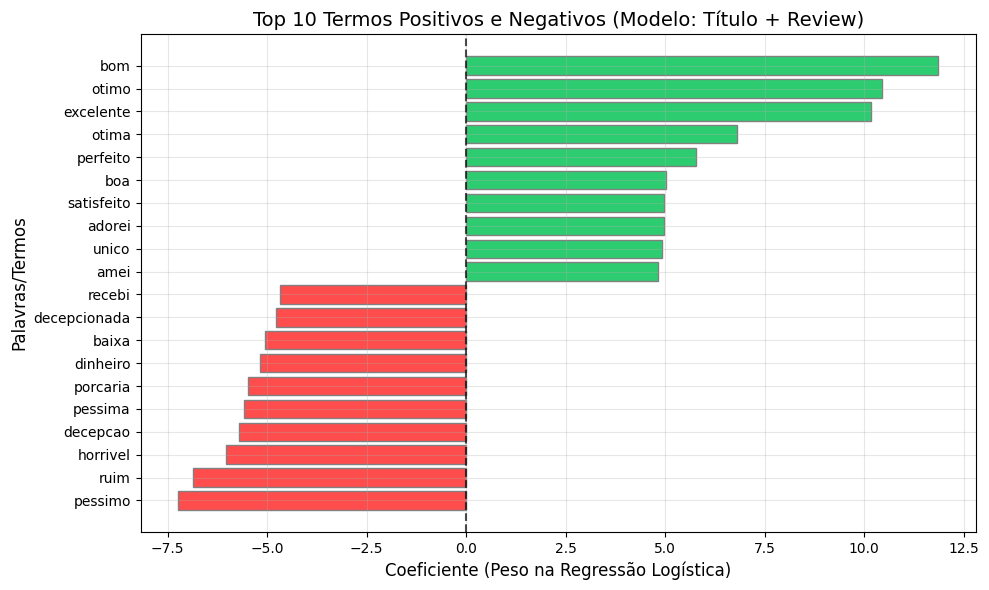

In [5]:
# Coeficientes e Termos mais significativos (Treinados no Dataset Completo)
vectorizer_full = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words=stop_words_pt
)
X_full = vectorizer_full.fit_transform(review_plus_title)
modelo_title_plus_review = LogisticRegression(max_iter=500, random_state=42)
modelo_title_plus_review.fit(X_full, y)

coefs = modelo_title_plus_review.coef_[0]
features = np.array(vectorizer_full.get_feature_names_out())

# Encontrando os 10 termos mais positivos e 10 mais negativos
top_positive_indices = np.argsort(coefs)[-10:]
top_negative_indices = np.argsort(coefs)[:10]

top_indices = np.hstack([top_negative_indices, top_positive_indices])
top_coefs = coefs[top_indices]
top_features = features[top_indices]

# Plotando a importância de termos
plt.figure(figsize=(10, 6))
colors = ['#ff4d4d' if c < 0 else '#2ecc71' for c in top_coefs]
plt.barh(top_features, top_coefs, color=colors, edgecolor='grey')
plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Top 10 Termos Positivos e Negativos (Modelo: Título + Review)', fontsize=14)
plt.xlabel('Coeficiente (Peso na Regressão Logística)', fontsize=12)
plt.ylabel('Palavras/Termos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.4 Matrizes de Confusão Out-of-Fold

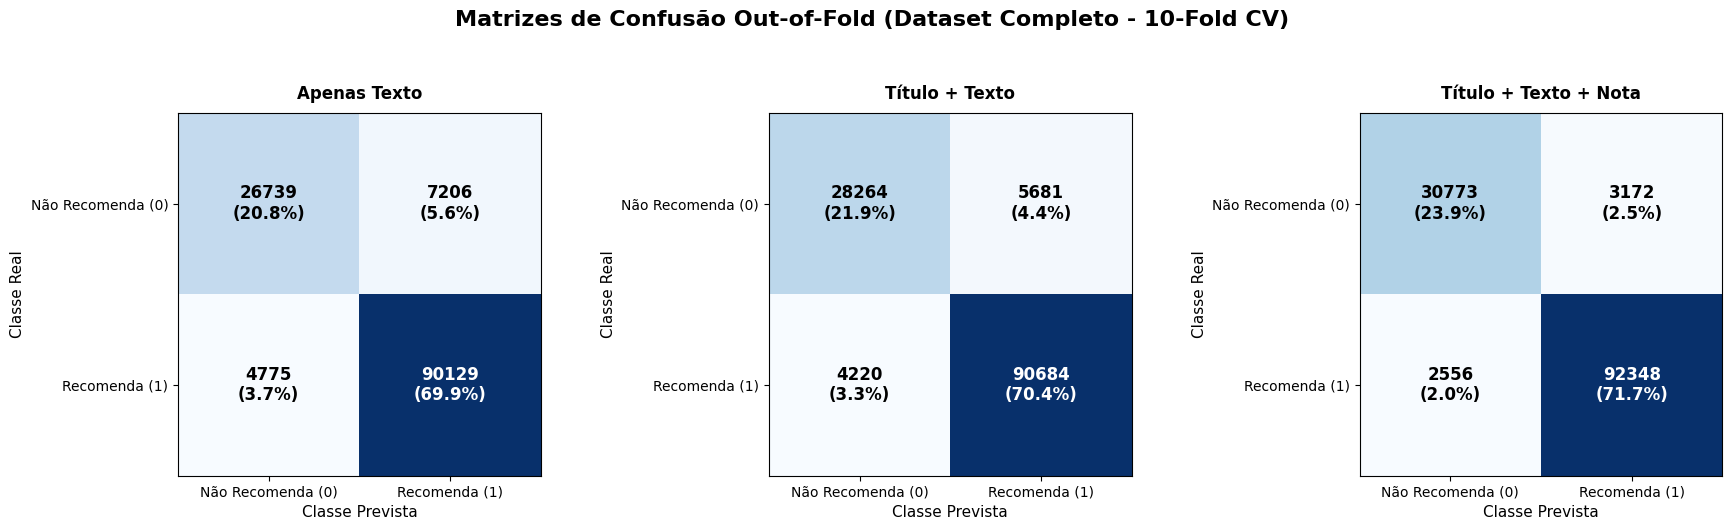


==== RELATÓRIO DE CLASSIFICAÇÃO OUT-OF-FOLD: APENAS TEXTO ====
              precision    recall  f1-score   support

           0       0.85      0.79      0.82     33945
           1       0.93      0.95      0.94     94904

    accuracy                           0.91    128849
   macro avg       0.89      0.87      0.88    128849
weighted avg       0.91      0.91      0.91    128849


==== RELATÓRIO DE CLASSIFICAÇÃO OUT-OF-FOLD: TÍTULO + TEXTO ====
              precision    recall  f1-score   support

           0       0.87      0.83      0.85     33945
           1       0.94      0.96      0.95     94904

    accuracy                           0.92    128849
   macro avg       0.91      0.89      0.90    128849
weighted avg       0.92      0.92      0.92    128849


==== RELATÓRIO DE CLASSIFICAÇÃO OUT-OF-FOLD: TÍTULO + TEXTO + NOTA ====
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     33945
           1       0.97      0.97 

In [6]:
# Estrutura de avaliação das etapas (Matrizes de Confusão OOF)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

configuracoes_oof = [
    ("Apenas Texto", oof_preds_c1),
    ("Título + Texto", oof_preds_c2),
    ("Título + Texto + Nota", oof_preds_c3)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrizes de Confusão Out-of-Fold (Dataset Completo - 10-Fold CV)', fontsize=16, fontweight='bold', y=1.05)

for idx, (nome_cenario, oof_pred) in enumerate(configuracoes_oof):
    ax = axes[idx]
    cm = confusion_matrix(y_arr, oof_pred)
    
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    
    thresh = cm.max() / 2.
    total = np.sum(cm)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            qtd = cm[r, c]
            pct = (qtd / total) * 100
            label = f"{qtd}\n({pct:.1f}%)"
            ax.text(c, r, label,
                    ha="center", va="center",
                    color="white" if qtd > thresh else "black",
                    fontsize=12, fontweight='bold')
            
    ax.set_title(nome_cenario, fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Não Recomenda (0)', 'Recomenda (1)'], fontsize=10)
    ax.set_yticklabels(['Não Recomenda (0)', 'Recomenda (1)'], fontsize=10)
    ax.set_ylabel('Classe Real', fontsize=11)
    ax.set_xlabel('Classe Prevista', fontsize=11)
    ax.grid(False)

plt.tight_layout()
plt.show()

# Exibição dos relatórios textuais OOF
for nome_cenario, oof_pred in configuracoes_oof:
    print(f"\n==== RELATÓRIO DE CLASSIFICAÇÃO OUT-OF-FOLD: {nome_cenario.upper()} ====")
    print(classification_report(y_arr, oof_pred))


### 3.5 Comparação da Distribuição da Acurácia nos Folds

/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_67986/3983461819.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(dados_plot, labels=rotulos, patch_artist=True, notch=True,


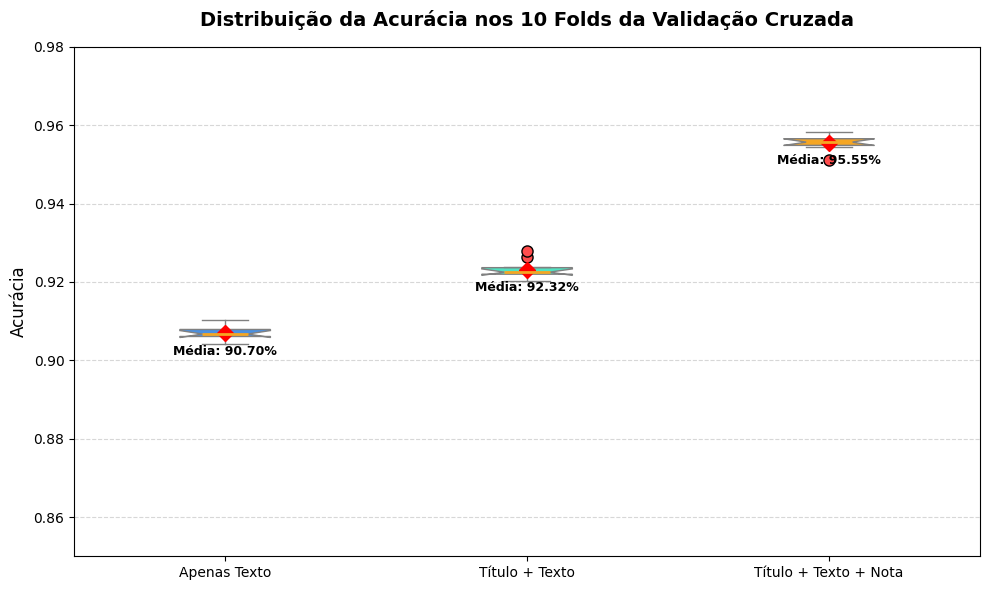

In [9]:
# Gráfico Comparativo de Acurácia: Distribuição dos 10 Folds
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

dados_plot = [accs_c1, accs_c2, accs_c3]
rotulos = ["Apenas Texto", "Título + Texto", "Título + Texto + Nota"]

# Customização do Boxplot para Rich Aesthetics
box = plt.boxplot(dados_plot, labels=rotulos, patch_artist=True, notch=True,
                  boxprops=dict(facecolor='#4A90E2', color='grey'),
                  capprops=dict(color='grey'),
                  whiskerprops=dict(color='grey'),
                  flierprops=dict(marker='o', markerfacecolor='#ff4d4d', markersize=8, linestyle='none'),
                  medianprops=dict(color='#F5A623', linewidth=2))

cores = ['#4A90E2', '#50E3C2', '#F5A623']
for patch, color in zip(box['boxes'], cores):
    patch.set_facecolor(color)

plt.title('Distribuição da Acurácia nos 10 Folds da Validação Cruzada', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adicionar a média no gráfico
for idx, accs in enumerate(dados_plot, 1):
    mean_val = np.mean(accs)
    plt.plot(idx, mean_val, marker='D', color='red', markersize=8)
    plt.text(idx, mean_val - 0.003, f"Média: {mean_val*100:.2f}%", ha='center', va='top', fontsize=9, color='black', fontweight='bold')

plt.ylim(0.85, 0.98)
plt.tight_layout()
plt.show()


### 3.6 Teste de hipótese: Comparação de Médias dos Modelos

#### Análise Metodológica: Holdout vs. K-Fold Cross-Validation

* **Utilizando Holdout (Única Divisão)**:
  Com uma única partição Holdout, obtemos apenas uma estimativa pontual de acurácia por modelo (ex.: $91\%$ vs $92\%$). Como a amostra de acurácias tem tamanho $N = 1$ para cada modelo, a variância do indicador de desempenho é nula, impossibilitando a aplicação do teste t pareado (que exige uma distribuição de valores para estimar a média e o desvio padrão da diferença).
  * *Alternativa no Holdout:* Seria possível aplicar o **Teste de McNemar**, que avalia a tabela de contingência das predições individuais (acertos/erros cruzados dos modelos na mesma amostra de teste).
  
* **Utilizando K-Fold Cross-Validation**:
  Para aplicar o **teste t pareado para diferença de médias**, precisamos de múltiplas observações pareadas de acurácia. A validação cruzada $10\text{-Fold}$ resolve essa limitação ao gerar $10$ estimativas independentes de acurácia para cada configuração do modelo, permitindo estimar a variância e realizar o teste de hipóteses de forma estatisticamente rigorosa.

Abaixo, realizamos os testes de normalidade (Shapiro-Wilk) e de hipótese (teste t pareado) a partir das acurácias obtidas nos 10 folds.


In [11]:
# Execução dos Testes de Hipótese (Shapiro-Wilk e Teste t Pareado)
from scipy import stats
import numpy as np

comparacoes = [
    ("Só review", "Título + review", accs_c1, accs_c2),
    ("Título + review", "Título + review + rating", accs_c2, accs_c3),
    ("Só review", "Título + review + rating", accs_c1, accs_c3)
]

print("====== VALIDAÇÃO DE PRESSUPOSTOS (TESTE SHAPIRO-WILK) ======")
for nomeA, nomeB, accsA, accsB in comparacoes:
    diff = accsA - accsB
    stat, p_val = stats.shapiro(diff)
    print(f"\nDiferença: ({nomeA}) vs ({nomeB})")
    print(f"Estatística Shapiro-Wilk = {stat:.4f}, p-valor = {p_val:.4f}")
    if p_val > 0.05:
        print("-> PRESSUPOSTO ATENDIDO: As diferenças seguem uma distribuição aproximadamente normal (p > 0.05).")
    else:
        print("-> AVISO: O pressuposto de normalidade foi rejeitado (p <= 0.05). O teste t pareado pode ser robusto a desvios, mas recomenda-se cautela.")

print("\n====== RESULTADOS DOS TESTES T PAREADOS (alfa = 0.05) ======")
for nomeA, nomeB, accsA, accsB in comparacoes:
    t_stat, p_val = stats.ttest_rel(accsA, accsB)
    mean_diff = np.mean(accsA - accsB)
    print(f"\nComparação: ({nomeA}) vs ({nomeB})")
    print(f"Média das diferenças (A - B): {mean_diff:.5f}")
    print(f"Estatística t = {t_stat:.4f}, p-valor = {p_val:.4g}")
    if p_val < 0.05:
        print(f"-> CONCLUSÃO: Há diferença estatisticamente significativa entre as médias de acurácia (p < 0.05).")
    else:
        print(f"-> CONCLUSÃO: Não há diferença estatisticamente significativa entre as médias de acurácia (p >= 0.05).")


====== VALIDAÇÃO DE PRESSUPOSTOS (TESTE SHAPIRO-WILK) ======

Diferença: (Só review) vs (Título + review)
Estatística Shapiro-Wilk = 0.9463, p-valor = 0.6248
-> PRESSUPOSTO ATENDIDO: As diferenças seguem uma distribuição aproximadamente normal (p > 0.05).

Diferença: (Título + review) vs (Título + review + rating)
Estatística Shapiro-Wilk = 0.9456, p-valor = 0.6173
-> PRESSUPOSTO ATENDIDO: As diferenças seguem uma distribuição aproximadamente normal (p > 0.05).

Diferença: (Só review) vs (Título + review + rating)
Estatística Shapiro-Wilk = 0.9183, p-valor = 0.3428
-> PRESSUPOSTO ATENDIDO: As diferenças seguem uma distribuição aproximadamente normal (p > 0.05).

====== RESULTADOS DOS TESTES T PAREADOS (alfa = 0.05) ======

Comparação: (Só review) vs (Título + review)
Média das diferenças (A - B): -0.01614
Estatística t = -38.6991, p-valor = 2.552e-11
-> CONCLUSÃO: Há diferença estatisticamente significativa entre as médias de acurácia (p < 0.05).

Comparação: (Título + review) vs (Títu

Nota:
Nota metodológica sobre múltiplas comparações:
Como realizamos 3 testes de hipótese na mesma amostra, há inflação do erro do tipo I global.
Para controlar esse erro (taxa de erro por família), a Correção de Bonferroni poderia ser aplicada.
Com ela, o nível de significância ajustado seria de alfa_ajustado = 0.05 / 3 = 0.0167.
Em um cenário rigoroso de validação ou publicação acadêmica, o p-valor de cada teste deve ser comparado a esse limite ajustado (0.0167) para confirmar a significância.

## 4. Abordagem Baseada em Aprendizado Profundo: DistilBERT (Fine-Tuning)

Transformers processam texto com base em representações contextuais ricas e atenção bidirecional. O pré-processamento para esta abordagem é diferente:
- **Não deve haver remoção de Stopwords:** Stopwords são fundamentais para construir a sintaxe e o contexto que o Transformer analisa.
- **Não remover acentuação:** Como usamos um modelo *cased* (`distilbert-base-multilingual-cased`), a pontuação e caixa carregam ênfase e sentimentos importantes.

> **Atenção:** Devido a limitações de hardware e tempo, o fine-tuning será efetuado em um subconjunto balanceado de **5.000 amostras** do conjunto de treino original. A validação e o teste ocorrem nos conjuntos completos para garantir comparação justa com a etapa do TF-IDF.

In [ ]:
# Definição de Hiperparâmetros e Amostragem do BERT
MODELO = "distilbert/distilbert-base-multilingual-cased"
MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 2
RANDOM_STATE = 42
N_TREINO_BERT = 5000  # Tamanho do subconjunto para treinamento

# Divisão Holdout local para o BERT
from sklearn.model_selection import train_test_split

(
    X_train_full_bert,
    X_test_full_bert,
    y_train_bert_temp,
    y_test_bert,
) = train_test_split(
    review_plus_title,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

(
    X_train_full_bert,
    X_val_full_bert,
    y_train_bert,
    y_val_bert,
) = train_test_split(
    X_train_full_bert,
    y_train_bert_temp,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_bert_temp,
)

df_tr = pd.DataFrame({
    "text": X_train_full_bert.astype(str),
    "label": y_train_bert.values,
})

# Amostragem estratificada para manter a proporção das classes
df_tr_sub, _ = train_test_split(
    df_tr,
    train_size=min(N_TREINO_BERT, len(df_tr)),
    stratify=df_tr["label"],
    random_state=RANDOM_STATE,
)

texto_treino_bert = df_tr_sub["text"].tolist()
y_treino_bert = df_tr_sub["label"].tolist()

texto_val_bert = X_val_full_bert.astype(str).tolist()
y_val_bert = y_val_bert.tolist()

texto_teste_bert = X_test_full_bert.astype(str).tolist()
y_teste_bert = y_test_bert.tolist()

print(f"Tamanhos das Partições: Treino={len(texto_treino_bert)}, Validação={len(texto_val_bert)}, Teste={len(texto_teste_bert)}")


In [ ]:
# Carregamento do Tokenizador, Modelo e Estrutura de Dataset PyTorch
tokenizer = AutoTokenizer.from_pretrained(MODELO)
model_distil = AutoModelForSequenceClassification.from_pretrained(
    MODELO,
    num_labels=2,
)

class ReviewDataset(Dataset):
    def __init__(self, textos, labels):
        self.encodings = tokenizer(
            list(textos),
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ReviewDataset(texto_treino_bert, y_treino_bert)
val_dataset = ReviewDataset(texto_val_bert, y_val_bert)
test_dataset = ReviewDataset(texto_teste_bert, y_teste_bert)

In [ ]:
# Inicialização do HuggingFace Trainer
training_args = TrainingArguments(
    output_dir="./distilbert_checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    learning_rate=2e-5,
    seed=RANDOM_STATE,
    report_to="none",
)

trainer = Trainer(
    model=model_distil,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Iniciar Treinamento
trainer.train()

In [ ]:
# Avaliação no Conjunto de Teste Completo (25.770 registros)
out_test = trainer.predict(test_dataset)
y_pred_distil = np.argmax(out_test.predictions, axis=1)

print("==== DISTILBERT - TESTE ====")
print(classification_report(y_teste_bert, y_pred_distil))
print("==== MATRIZ DE CONFUSÃO ====")
print(confusion_matrix(y_teste_bert, y_pred_distil))
print("Acurácia Final:", accuracy_score(y_teste_bert, y_pred_distil))

## 5. Análise de Resultados e Comparativo Final

### Tabela Geral de Métricas (Conjunto de Teste)

| Abordagem / Configuração | Acurácia | F1-Score (Classe 0) | F1-Score (Classe 1) |
| :--- | :---: | :---: | :---: |
| TF-IDF + Reg. Logística (Só Review) | 0.9131 | 0.83 | 0.94 |
| TF-IDF + Reg. Logística (Título + Review) | 0.9302 | 0.87 | 0.95 |
| TF-IDF + Reg. Logística (Título + Review + Rating) | **0.9563** | **0.92** | **0.97** |
| **DistilBERT** (Fine-Tuning - 5k treino) | 0.9235 | 0.86 | 0.95 |

### Análise Crítica dos Resultados
- O modelo **TF-IDF + Regressão Logística** com Nota (Rating) foi a abordagem mais eficaz no teste devido ao forte sinal de polaridade contido na nota númerica (1 a 5).
- O **DistilBERT** com apenas o texto obteve acurácia comparável (92.35%) ao melhor baseline de texto do TF-IDF (93.02%), mesmo tendo sido treinado em um subconjunto reduzido de dados (5.000 amostras vs 82.463 amostras da Regressão Logística), destacando o potencial de generalização dos Transformers.

## 6. Análise Qualitativa de Erros

Identificamos quatro padrões linguísticos onde os modelos apresentam divergência sistemática:

### Exemplo 1: Regressão Logística Erra / DistilBERT Acerta
- **Texto (Review):** Título: "Linha Rosa (Linha da Morte)" | Corpo: *"O produto é excelente porém o aparelho que recebi [...] fiquei muito decepcionado [...] a Samsung sabe desse problema mas trata como algo casual"*
- **Rótulo Real:** Negativo (0)
- **Explicação:** A palavra *"excelente"* possui um peso estatístico positivo muito forte para o TF-IDF. Porém, o sentido geral é alterado pela adversativa *"porém"* e o termo de decepção subsequente. O DistilBERT compreende a estrutura sintática de dependência do texto e infere o rótulo negativo corretamente.

### Exemplo 2: Regressão Logística Erra / DistilBERT Acerta
- **Texto (Review):** Título: "Útil, mas frágil" | Corpo: *"O produto é ótimo para limpeza [...] Só que o cabo desse é muito frágil e curto [...] pra mim é bem ruim usar"*
- **Rótulo Real:** Negativo (0)
- **Explicação:** Há uma forte mistura de lexemas opostos (*útil, ótimo* vs *frágil, ruim*). A Regressão Logística baseada em bag-of-words confunde-se com as frequências relativas, enquanto o DistilBERT resolve a polaridade usando a representação de contexto e o contraste no título.

### Exemplo 3: DistilBERT Erra / Regressão Logística Acerta
- **Texto (Review):** Título: (Avaliação de entrega lenta) | Corpo: *"O produto é muito bom, mas tive problemas com a entrega [...] Só depois de 20 dias [...] Portanto eu recomendo o produto, mas não recomendo a loja"*
- **Rótulo Real:** Positivo (1) — Recomenda o produto
- **Explicação:** O texto contém frases como *"não recomendo a loja"*. O DistilBERT interpreta o forte sentimento negativo do relato de entrega e classifica como classe 0. A Regressão Logística, somando a contagem de termos positivos direcionados ao produto (*"muito bom"*, *"recomendo o produto"*), atribui peso suficiente para manter o rótulo positivo.

### Exemplo 4: Ambos Falham / Inconsistência
- **Texto (Review):** Título: "Amei o produto" | Corpo: *"Jogo de panelas excelente material, entrega a tempo, design muito bom."*
- **Rótulo Real:** Negativo (0)
- **Explicação:** Há uma nítida inconsistência entre o texto (totalmente positivo) e o rótulo atribuído no dataset. Nestes casos, o erro dos modelos decorre de ruído de anotação na coleta original dos dados.